## Analyzing a real world data-set with SQL and Python

In [1]:
# extension that allows you to execute SQL queries using "magic" commands (%sql)
!pip install ipython-sql   

## enables the execution of SQL queries directly within Jupyter cells.
%load_ext sql       

# data visualization library
!pip install seaborn       

# plotting library 
!pip install matplotlib

In [2]:
import csv, sqlite3

In [3]:
con = sqlite3.connect("inspection.db")
cur = con.cursor()
!pip install pandas

%sql sqlite:///inspection.db


In [4]:
import pandas as pd

df_inspection = pd.read_csv("C:/Program Files/MySQL/Food_Inspections_20251013.csv")

# Replace spaces with underscores in all column names
df_inspection.columns = df_inspection.columns.str.replace(' ', '_')

# convert all to lowercase
df_inspection.columns = df_inspection.columns.str.lower()

## engine = create_engine('sqlite:///:memory:')
df_inspection.to_sql("inspection_data", con, if_exists='replace', index=False)


298345

In [5]:
df_inspection.columns

Index(['inspection_id', 'dba_name', 'aka_name', 'license_#', 'facility_type',
       'risk', 'address', 'city', 'state', 'zip', 'inspection_date',
       'inspection_type', 'results', 'violations', 'latitude', 'longitude',
       'location'],
      dtype='object')

In [16]:
df_inspection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298345 entries, 0 to 298344
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   inspection_id    298345 non-null  int64  
 1   dba_name         298345 non-null  object 
 2   aka_name         295933 non-null  object 
 3   license_#        298327 non-null  float64
 4   facility_type    293083 non-null  object 
 5   risk             298260 non-null  object 
 6   address          298345 non-null  object 
 7   city             298183 non-null  object 
 8   state            298287 non-null  object 
 9   zip              298303 non-null  float64
 10  inspection_date  298345 non-null  object 
 11  inspection_type  298344 non-null  object 
 12  results          298345 non-null  object 
 13  violations       215173 non-null  object 
 14  latitude         297327 non-null  float64
 15  longitude        297327 non-null  float64
 16  location         297327 non-null  obje

In [17]:
df_inspection.describe()

,inspection_id,license_#,zip,latitude,longitude
count,2.983450e+05,2.983270e+05,298303.000000,297327.000000,297327.000000
mean,1.820302e+06,1.776294e+06,60628.711535,41.880625,-87.676357
std,7.317064e+05,9.408270e+05,165.235354,0.081094,0.058278
min,4.424700e+04,0.000000e+00,10014.000000,41.644670,-87.906874
25%,1.353215e+06,1.404354e+06,60614.000000,41.831504,-87.707434
50%,2.028415e+06,2.083833e+06,60625.000000,41.891814,-87.666524
75%,2.523107e+06,2.431752e+06,60643.000000,41.939765,-87.634955
max,2.625168e+06,9.999999e+06,91706.000000,42.021064,-87.525094


In [19]:
df_inspection.head()

,inspection_id,dba_name,aka_name,license_#,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2625151,SUFFRON,SUFFRON,2890569.0,Restaurant,Risk 1 (High),2459 W ARMITAGE AVE,CHICAGO,IL,60647.0,10/09/2025,Canvass Re-Inspection,Pass,NaN,41.917445,-87.689792,"(41.91744465934002, -87.68979177844926)"
1,2625112,Tri-Star Catering,Tri-Star Catering,3041130.0,Catering,Risk 1 (High),1752 W GRAND AVE,CHICAGO,IL,60622.0,10/09/2025,Canvass,Fail,8. HANDS CLEAN & PROPERLY WASHED - Comments: O...,41.891019,-87.671712,"(41.89101873935143, -87.67171200983539)"
2,2625098,Buffalo Wild Wings,Buffalo Wild Wings,3052109.0,Restaurant,Risk 2 (Medium),707 S SEELEY AVE,CHICAGO,IL,60612.0,10/09/2025,License,Pass,"38. INSECTS, RODENTS, & ANIMALS NOT PRESENT - ...",41.873026,-87.677454,"(41.8730261201771, -87.67745368604682)"
3,2625150,ODGE'S RESTAURANT,ODGE'S RESTAURANT,2348486.0,Restaurant,Risk 1 (High),730 N DAMEN AVE,CHICAGO,IL,60622.0,10/09/2025,Canvass,Fail,9. NO BARE HAND CONTACT WITH RTE FOOD OR A PRE...,41.895001,-87.677171,"(41.89500136818066, -87.67717110170229)"
4,2625111,ELVIA GAMA,LOS GAMAS TORTILLAS Y RESTORANTE,2423902.0,Restaurant,Risk 1 (High),3333 W ARMITAGE AVE,CHICAGO,IL,60647.0,10/09/2025,Canvass,Fail,49. NON-FOOD/FOOD CONTACT SURFACES CLEAN - Com...,41.917235,-87.711659,"(41.91723544708353, -87.71165855157675)"


In [6]:
# Install 'prettytable' libraries using pip
!pip install prettytable

In [7]:
# Import the 'prettytable' library, which is used to display data in a formatted table
import prettytable


In [8]:
# Set the default display format for prettytable to 'DEFAULT' (i.e., a simple table format)
prettytable.DEFAULT = 'DEFAULT'


In [9]:
%sql SELECT risk, COUNT(*) as estab FROM inspection_data GROUP BY risk ORDER BY estab DESC;

 * sqlite:///inspection.db
Done.


risk,estab
Risk 1 (High),220941
Risk 2 (Medium),53762
Risk 3 (Low),23482
None,85
All,75


In [10]:
%sql SELECT facility_type, COUNT(*) AS types FROM inspection_data GROUP BY facility_type ORDER BY types DESC LIMIT 12;

 * sqlite:///inspection.db
Done.


facility_type,types
Restaurant,201584
Grocery Store,36270
School,18792
Children's Services Facility,7080
None,5262
Bakery,4290
Daycare Above and Under 2 Years,3946
Daycare (2 - 6 Years),3178
Long Term Care,2313
Catering,1845


In [11]:
%sql SELECT inspection_type, COUNT(*) as types FROM inspection_data GROUP by inspection_type ORDER BY types DESC LIMIT 12;

 * sqlite:///inspection.db
Done.


inspection_type,types
Canvass,154507
License,39928
Canvass Re-Inspection,33429
Complaint,27967
License Re-Inspection,12355
Complaint Re-Inspection,11752
Short Form Complaint,8865
Non-Inspection,4705
Suspected Food Poisoning,991
Consultation,679


In [12]:
%sql SELECT inspection_id, dba_name, facility_type, inspection_type, risk, results FROM inspection_data limit 5;

 * sqlite:///inspection.db
Done.


inspection_id,dba_name,facility_type,inspection_type,risk,results
2625151,SUFFRON,Restaurant,Canvass Re-Inspection,Risk 1 (High),Pass
2625112,Tri-Star Catering,Catering,Canvass,Risk 1 (High),Fail
2625098,Buffalo Wild Wings,Restaurant,License,Risk 2 (Medium),Pass
2625150,ODGE'S RESTAURANT,Restaurant,Canvass,Risk 1 (High),Fail
2625111,ELVIA GAMA,Restaurant,Canvass,Risk 1 (High),Fail


In [13]:
import seaborn as sns


In [14]:
%sql SELECT results, risk FROM inspection_data  LIMIT 12;

 * sqlite:///inspection.db
Done.


results,risk
Pass,Risk 1 (High)
Fail,Risk 1 (High)
Pass,Risk 2 (Medium)
Fail,Risk 1 (High)
Fail,Risk 1 (High)
Fail,Risk 1 (High)
Out of Business,Risk 2 (Medium)
Fail,Risk 1 (High)
Pass,Risk 1 (High)
Not Ready,Risk 1 (High)


 * sqlite:///inspection.db
Done.


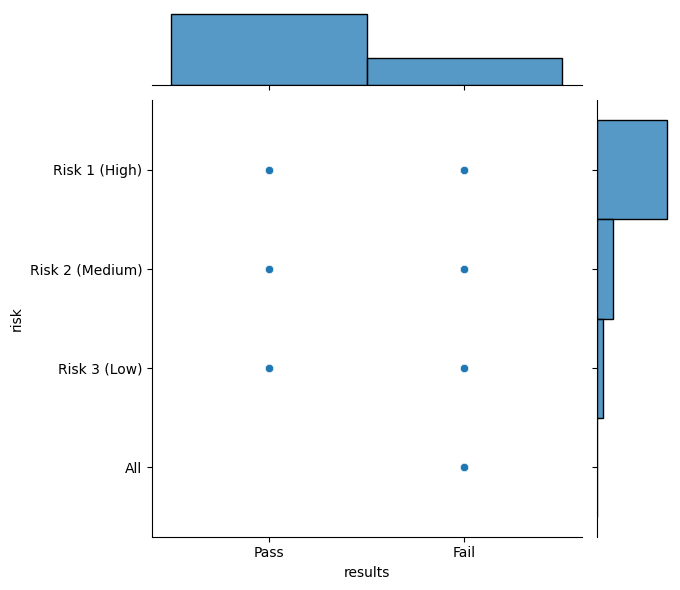

In [15]:
results_vs_risk = %sql SELECT results, risk FROM inspection_data WHERE results = 'Pass' OR results = 'Fail' or 'Not Ready';

plot = sns.jointplot(x='results',y='risk', data=results_vs_risk.DataFrame())


In [20]:
cases_risk_all_results = %sql SELECT SUBSTR(inspection_date, 7, 4) AS year, results,  COUNT(*) as cases \
    FROM inspection_data  \
    GROUP BY year, results;

 * sqlite:///inspection.db
Done.


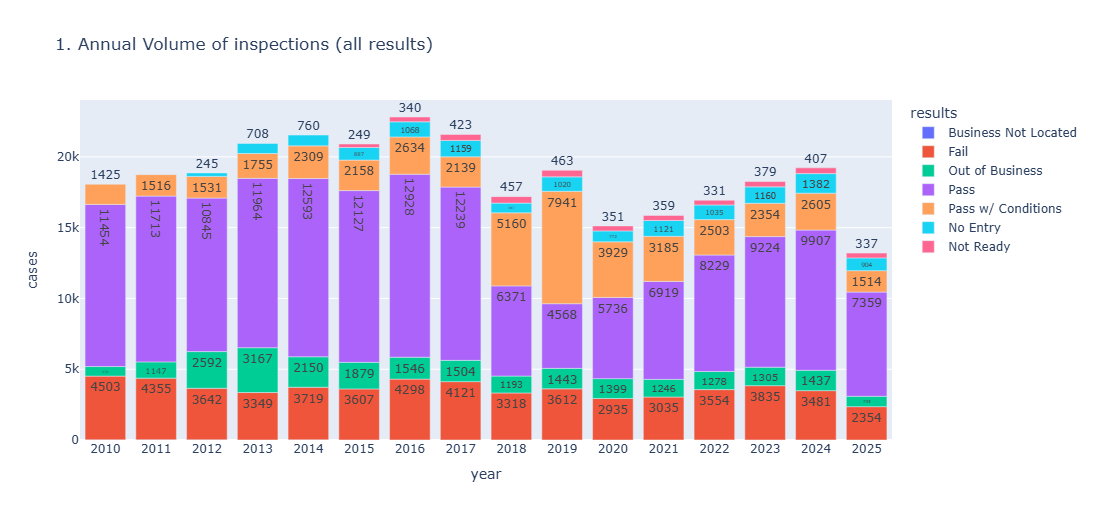

In [21]:
import plotly.express as px

fig = px.bar(
    cases_risk_all_results,
    x='year',
    y='cases',
    text='cases',
    color='results',
    title='1. Annual Volume of inspections (all results)',
    width=1000,
    height=520
)

fig.show()

Inspections are classified as "Pass," "Pass with Conditions," and "Fail." The graph of the evolution of inspection result categories shows several points that can be used for analysis.

For example, starting in 2018, the pass criteria became more stringent, significantly increasing the number of pass-with-condition results.

# 3. Annual volume of restaurants approved with condition for inspection by risk category

In [25]:
cases_all_risk_condition = %sql SELECT SUBSTR(inspection_date, 7, 4) AS year, risk, results, COUNT(*) as cases \
    FROM inspection_data WHERE results  like '%Conditions' \
    GROUP BY year, risk;

 * sqlite:///inspection.db
Done.


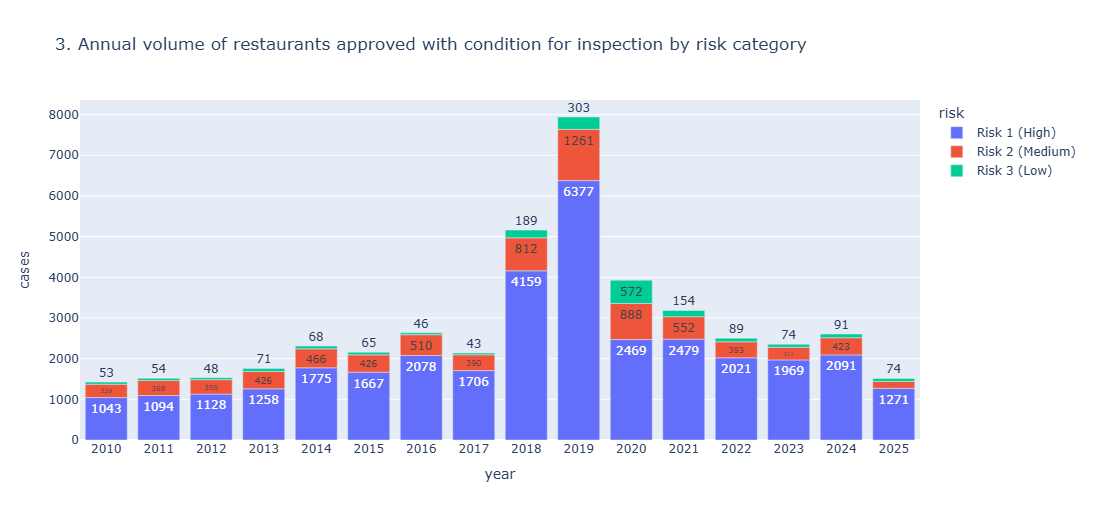

In [26]:
import plotly.express as px

fig = px.bar(
    cases_all_risk_condition,
    x='year',
    y='cases',
    text='cases',
    color='risk',
    title='3. Annual volume of restaurants approved with condition for inspection by risk category',
    width=1000,
    height=520
)

fig.show()